In [2]:
import pandas as pd
df=pd.read_csv("D:\\biotechtrek python\\Gene_expression (1).csv")
print(df)

    Gene  Control_1  Control_2  Treated_1  Treated_2
0   TP53        5.2        5.5        8.1        8.3
1  BRCA1        3.1        3.0        2.2        2.4
2    MYC        7.5        7.8       10.2       10.5
3   EGFR        4.2        4.0        6.5        6.8
4  GAPDH        9.0        9.1        9.2        9.3
5   ACTB        8.5        8.6        8.7        8.8
6   CDK1        2.5        2.7        5.0        5.2
7   BCL2        3.3        3.5        2.0        2.1
8  VEGFA        4.8        4.9        7.0        7.2
9    TNF        2.0        2.1        4.5        4.7


In [ ]:
#check the dataset

In [6]:
df.columns

Index(['Gene', 'Control_1', 'Control_2', 'Treated_1', 'Treated_2'], dtype='object')

In [62]:
rows,columns= df.shape
print(f"number of rows:{rows}, number of columns:{columns}")

number of rows:10, number of columns:9


In [60]:
rows= df.shape[0]
print("number of rows:",rows)

number of rows: 10


In [14]:
def average(column):
    return df[column].mean()
print("average expression for Control_1 =", average("Control_1"))
print("average expression for Control_2 =",average("Control_2"))
print("average expression for Treated_1 =",average("Treated_1"))
print("average expression for Treated_1 =",average("Treated_2"))

average expression for Control_1 = 5.01
average expression for Control_2 = 5.12
average expression for Treated_1 = 6.34
average expression for Treated_1 = 6.530000000000001


In [ ]:
#Compare the expression between the conditions 

In [13]:

df.columns

Index(['Gene', 'Control_1', 'Control_2', 'Treated_1', 'Treated_2',
       'Difference-1', 'Difference_2', 'Difference_1'],
      dtype='object')

In [ ]:
#identify genes with increased and decreased expression

In [3]:
import pandas as pd
df=pd.read_csv("D:\\biotechtrek python\\Gene_expression (1).csv")

df["Difference_1"]=df["Treated_1"]-df["Control_1"]
df

,Gene,Control_1,Control_2,Treated_1,Treated_2,Difference_1
0,TP53,5.2,5.5,8.1,8.3,2.9
1,BRCA1,3.1,3.0,2.2,2.4,-0.9
2,MYC,7.5,7.8,10.2,10.5,2.7
3,EGFR,4.2,4.0,6.5,6.8,2.3
4,GAPDH,9.0,9.1,9.2,9.3,0.2
5,ACTB,8.5,8.6,8.7,8.8,0.2
6,CDK1,2.5,2.7,5.0,5.2,2.5
7,BCL2,3.3,3.5,2.0,2.1,-1.3
8,VEGFA,4.8,4.9,7.0,7.2,2.2
9,TNF,2.0,2.1,4.5,4.7,2.5


In [4]:
df["Difference_2"]=df["Treated_2"]-df["Control_2"]
df

,Gene,Control_1,Control_2,Treated_1,Treated_2,Difference_1,Difference_2
0,TP53,5.2,5.5,8.1,8.3,2.9,2.8
1,BRCA1,3.1,3.0,2.2,2.4,-0.9,-0.6
2,MYC,7.5,7.8,10.2,10.5,2.7,2.7
3,EGFR,4.2,4.0,6.5,6.8,2.3,2.8
4,GAPDH,9.0,9.1,9.2,9.3,0.2,0.2
5,ACTB,8.5,8.6,8.7,8.8,0.2,0.2
6,CDK1,2.5,2.7,5.0,5.2,2.5,2.5
7,BCL2,3.3,3.5,2.0,2.1,-1.3,-1.4
8,VEGFA,4.8,4.9,7.0,7.2,2.2,2.3
9,TNF,2.0,2.1,4.5,4.7,2.5,2.6


In [43]:
def increased_gene_expression(column):
    index=df[column].idxmax()
    gene=df.loc[index,"Gene"]
    column=df[column].max()

    return index,gene,column

index,gene,value=increased_gene_expression("Treated_1")
print(f"The increased gene expression occured in Treated_1 sample in row {index},by gene {gene},with Expression value of {value}")
index,gene,value=increased_gene_expression("Treated_2")
print(f"The increased gene expression occured in Treated_2 sample in row {index},by gene {gene},with Expression value of {value}")



The increased gene expression occured in Treated_1 sample in row 2,by gene MYC,with Expression value of 10.2
The increased gene expression occured in Treated_2 sample in row 2,by gene MYC,with Expression value of 10.5


In [44]:
def decreased_gene_expression(column):
    index=df[column].idxmin()
    gene=df.loc[index,"Gene"]
    value=df[column].min()

    return index,gene,value

index,gene,value=decreased_gene_expression("Treated_1")
print(f"The decreased gene expression occured in Treated_1 sample in row {index},by gene {gene},with Expression value of {value}")
index,gene,value=decreased_gene_expression("Treated_2")
print(f"The decreased gene expression occured in Treated_2 sample in row {index},by gene {gene},with Expression value of {value}")

The decreased gene expression occured in Treated_1 sample in row 7,by gene BCL2,with Expression value of 2.0
The decreased gene expression occured in Treated_2 sample in row 7,by gene BCL2,with Expression value of 2.1


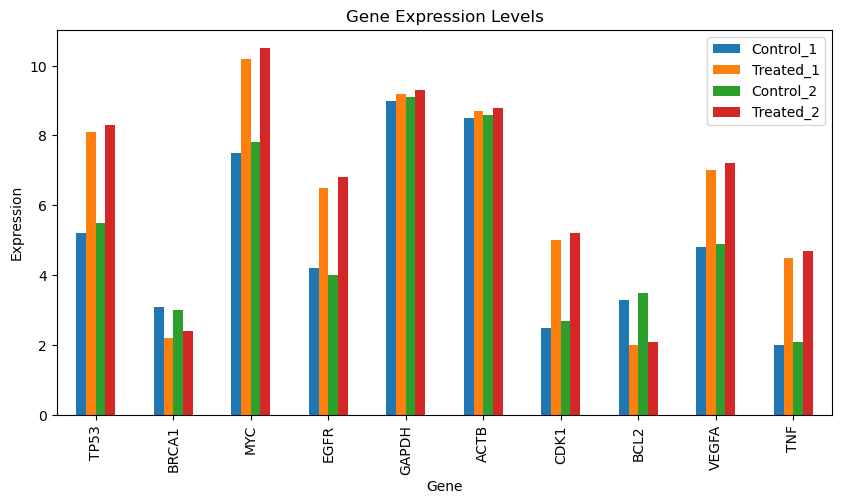

In [54]:
#visualization of results

import matplotlib.pyplot as plt

#comparing the Control and Treated values for each sample using bar graphs

df.plot(x="Gene",
        y=["Control_1","Treated_1","Control_2","Treated_2"],
        kind="bar",
        figsize=(10,5))

plt.title("Gene Expression Levels")
plt.xlabel("Gene")
plt.ylabel("Expression")
plt.show()

In [57]:
df["Control_mean"]=df[["Control_1","Control_2"]].mean(axis=1)
df["Treated_mean"]=df[["Treated_1","Treated_2"]].mean(axis=1)
df

,Gene,Control_1,Control_2,Treated_1,Treated_2,Difference_1,Difference_2,Control_mean,Treated_mean
0,TP53,5.2,5.5,8.1,8.3,2.9,2.8,5.35,8.20
1,BRCA1,3.1,3.0,2.2,2.4,-0.9,-0.6,3.05,2.30
2,MYC,7.5,7.8,10.2,10.5,2.7,2.7,7.65,10.35
3,EGFR,4.2,4.0,6.5,6.8,2.3,2.8,4.10,6.65
4,GAPDH,9.0,9.1,9.2,9.3,0.2,0.2,9.05,9.25
5,ACTB,8.5,8.6,8.7,8.8,0.2,0.2,8.55,8.75
6,CDK1,2.5,2.7,5.0,5.2,2.5,2.5,2.60,5.10
7,BCL2,3.3,3.5,2.0,2.1,-1.3,-1.4,3.40,2.05
8,VEGFA,4.8,4.9,7.0,7.2,2.2,2.3,4.85,7.10
9,TNF,2.0,2.1,4.5,4.7,2.5,2.6,2.05,4.60


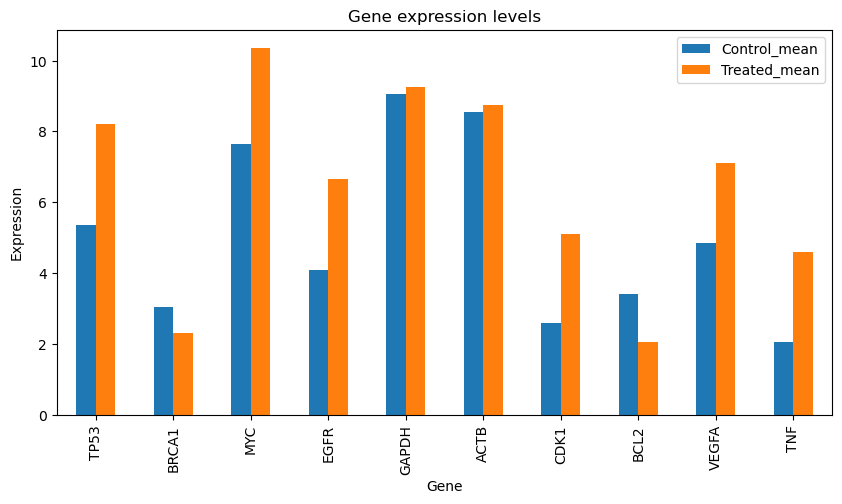

In [59]:
df.plot(x="Gene",y=["Control_mean","Treated_mean"],kind="bar",figsize=(10,5))
plt.title("Gene expression levels")
plt.xlabel("Gene")
plt.ylabel("Expression")
plt.show()